<Axes: title={'center': 'Z Slice'}>

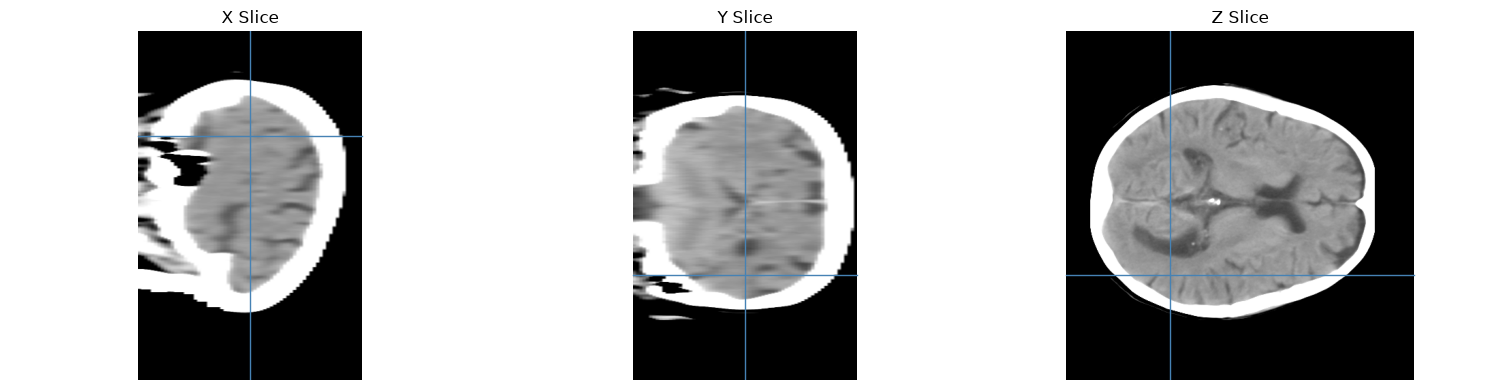

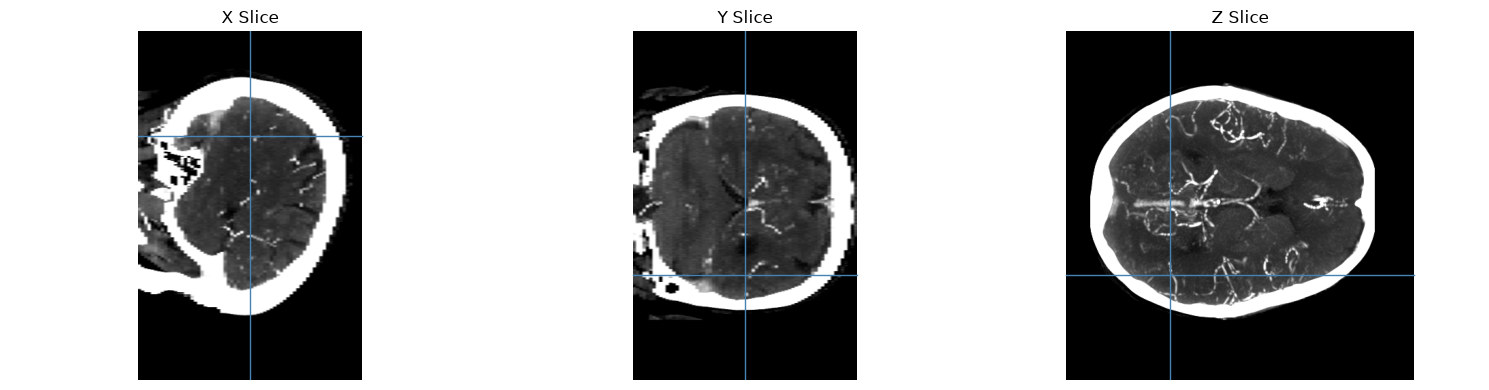

In [41]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import nibabel as nib
import matplotlib.pyplot as plt

data_path = "../nnUNet_raw/Dataset/"

inputs = os.path.join(data_path, "imagesTr")
outputs = os.path.join(data_path, "labelsTr")
id_to_4digit = lambda id: str(id).zfill(4)
patient_input = lambda id: os.path.join(inputs, f"case_{id_to_4digit(id)}_0000.nii.gz")
patient_output = lambda id: os.path.join(outputs, f"case_{id_to_4digit(id)}_0001.nii.gz")


class NCCT_CUTOFF:
    LOWER = -20 # HU soft tissue
    UPPER = 60  # HU bone
    
class CTA_CUTOFF:
    LOWER = -0   # HU blood
    UPPER = 200 # HU contrast agent

class NiiPoint():
    @ staticmethod
    def from_path(path, device, tfm=None):
        nii = nib.load(path)
        data_np = nii.get_fdata()
        data = torch.from_numpy(data_np).to(device)
        return NiiPoint(data, nii.affine, nii.header, device, tfm)
    
    def __init__(self, data, affine, header, device, tfm=None):
        self.data = data.to(device)
        if tfm is not None:
            self.data = tfm(self.data)
        self.affine = affine
        self.header = header
        
    
    def __add__(self, other):
        assert self.data.shape == other.data.shape, "Data shapes must match for addition"
        result = NiiPoint(self.data.clone(), self.affine, self.header, self.data.device)
        result.data = self.data + other.data
        return result
    
    def __sub__(self, other):
        assert self.data.shape == other.data.shape, "Data shapes must match for subtraction"
        result = NiiPoint(self.data.clone(), self.affine, self.header, self.data.device)
        result.data = self.data - other.data
        return result
    
    def __mul__(self, other):
        if other.__class__ == float or other.__class__ == int:
            result = NiiPoint(self.data.clone(), self.affine, self.header, self.data.device)
            result.data = self.data * other
            return result
        else:    
            assert self.data.shape == other.data.shape, "Data shapes must match for multiplication"
            result = NiiPoint(self.data.clone(), self.affine, self.header, self.data.device)
            result.data = self.data * other.data
            return result
    
    
    def apply_tfm(self, tfm):
        new = NiiPoint(self.data.clone(), self.affine, self.header, self.data.device)
        new.data = tfm(new.data, new.affine, new.header)
        return new
        
        
    def plot_slices(self, slices, thicknesses=None,**kwargs):
        data_np = self.data.cpu().numpy()
        pixdim = self.header.get_zooms()
    
        idx = [int(slices[i] * data_np.shape[i]) for i in range(3)]

        # Axes: (X, Y, Z) = (width, height, depth)
        if thicknesses is None:
            slice_data = [
                data_np[idx[0], :, :],
                data_np[:, idx[1], :],
                data_np[:, :, idx[2]]
            ]
        elif thicknesses == "all":
            slice_data = [
                data_np.max(axis=0),
                data_np.max(axis=1),
                data_np.max(axis=2)
            ]
            
        else:
            slice_data = [
                data_np[idx[0]-thicknesses[0]:idx[0]+thicknesses[0], :, :].max(axis=0),
                data_np[:, idx[1]-thicknesses[1]:idx[1]+thicknesses[1], :].max(axis=1),
                data_np[:, :, idx[2]-thicknesses[2]:idx[2]+thicknesses[2]].max(axis=2)
            ]
        
        pos_slices = [idx[i] * pixdim[i] for i in range(3)]
        slice_widths = [pixdim[i] * data_np.shape[i] for i in range(3)]
        
        plt.figure(figsize=(15, 4))
        for i in range(3):
            plt.subplot(1, 3, i+1)
            j2, j1 = [j for j in range(3) if j != i]
            plt.imshow(slice_data[i], extent=[0, slice_widths[j1], 0, slice_widths[j2]], cmap='gray', **kwargs)
            plt.plot([pos_slices[j1], pos_slices[j1]], [0, slice_widths[j2]], 'steelblue', linewidth=1)
            plt.plot([0, slice_widths[j1]], [slice_widths[j2]-pos_slices[j2], slice_widths[j2]-pos_slices[j2]], 'steelblue', linewidth=1)
            plt.title(f'{["X", "Y", "Z"][i]} Slice')
            plt.axis("equal")
            plt.axis('off')
        
        plt.tight_layout()
        return plt.gca()
        
    
def ncct_tfm(data, affine=None, header=None):
    data = torch.clamp(data, min=NCCT_CUTOFF.LOWER, max=NCCT_CUTOFF.UPPER)
    data = (data - NCCT_CUTOFF.LOWER) / (NCCT_CUTOFF.UPPER - NCCT_CUTOFF.LOWER)
    #data = torch.where(data == 1, torch.tensor(0.0, device=data.device), data)
    return data


def cta_tfm(data, affine=None, header=None):
    data = torch.clamp(data, min=CTA_CUTOFF.LOWER, max=CTA_CUTOFF.UPPER)
    data = (data - CTA_CUTOFF.LOWER) / (CTA_CUTOFF.UPPER - CTA_CUTOFF.LOWER)
    #data = torch.where(data == 1, torch.tensor(0.0, device=data.device), data)
    return data

idx = 102#102
data_inp_raw = NiiPoint.from_path(patient_input(idx), "cuda")
data_out_raw = NiiPoint.from_path(patient_output(idx), "cuda")
data_inp = data_inp_raw.apply_tfm(ncct_tfm)
data_out = data_out_raw.apply_tfm(cta_tfm)


slices = (0.7, 0.3, 0.5)
data_inp.plot_slices(slices, (1, 1, 1))
data_out.plot_slices(slices, (5, 5, 5))

# Processing

To extract the useful features (which we will try to learn), we first create a bone mask from the NCCT data by a simple thresholding + Gaussian blur, to create a smooth partition of unity. We then use the NCCT bone mask to segment the CTA data, combined with a soft/hard tissue threshold split, to create three separate maps: Bone, Soft, vessel. Out of these, it's the vessel component that sets CTA apart from NCCT, and should be the component that we train on. 


[9, 9, 3]
max/min: tensor(2128., device='cuda:0', dtype=torch.float64) tensor(-1043., device='cuda:0', dtype=torch.float64)


<Axes: title={'center': 'Z Slice'}>

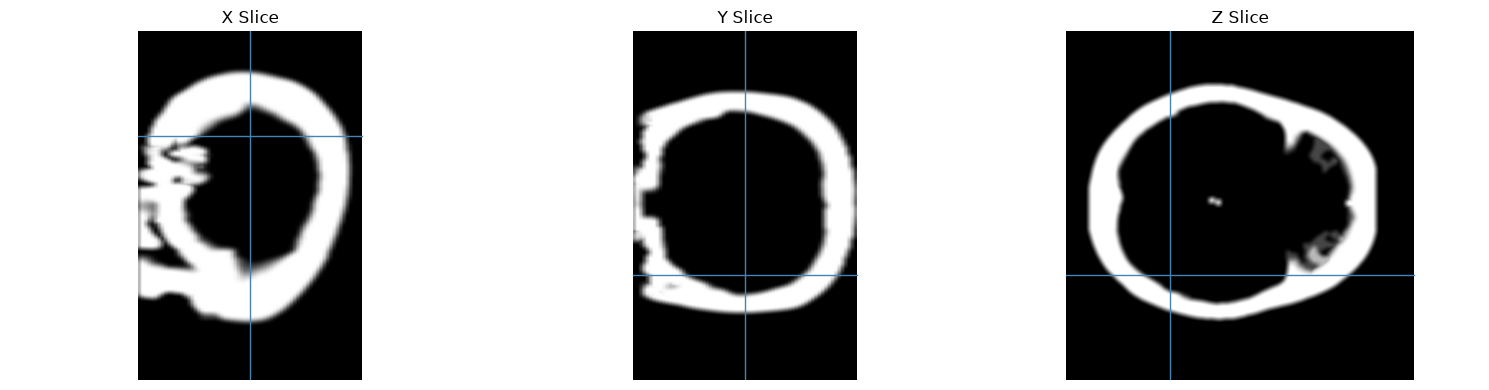

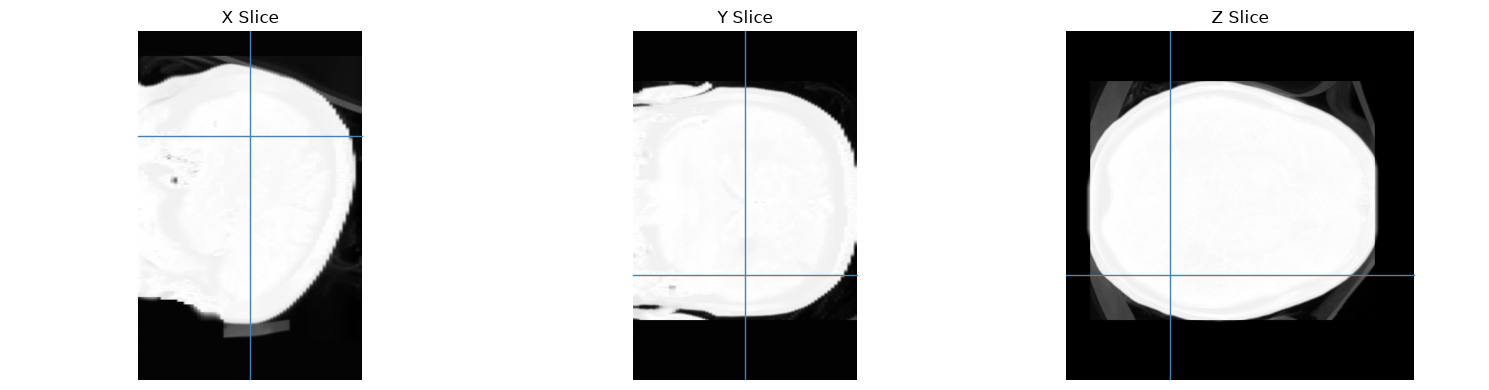

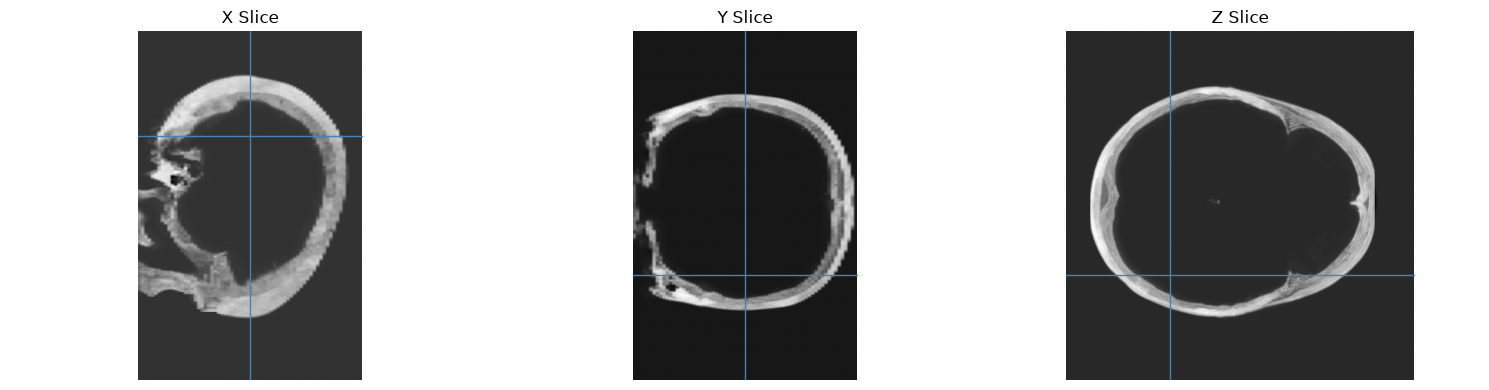

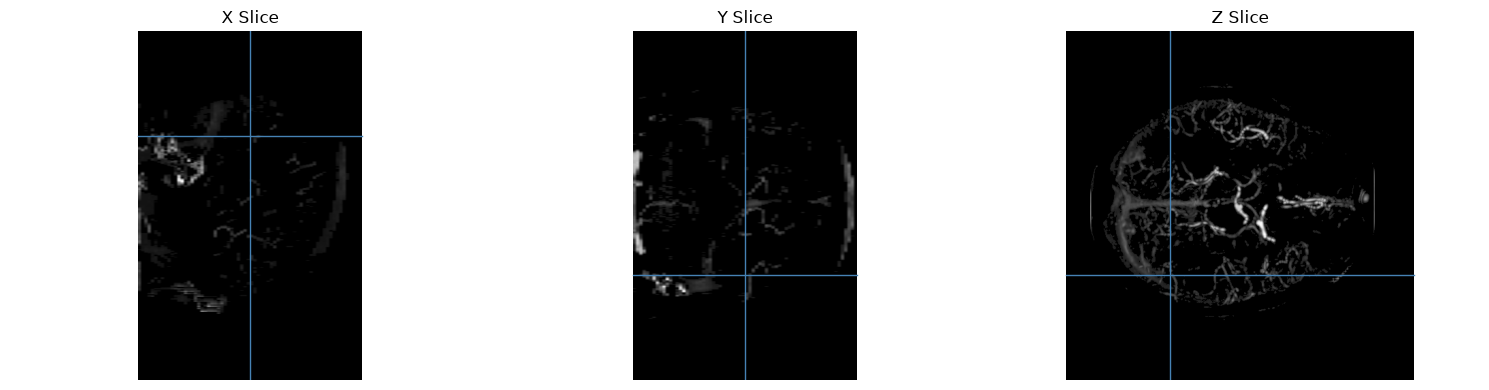

In [42]:
def expand_mask(mask, thickness, pixdim):
    # Expand the mask by a given thickness in all directions
    kernel_size = [2 *int(thickness / pixdim[i]) + 1 for i in range(3)]
    padding = [k // 2 for k in kernel_size]
    mask = mask.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    expanded_mask = torch.nn.functional.max_pool3d(mask.float(), kernel_size=kernel_size, stride=1, padding=padding)
    return expanded_mask.squeeze(0).squeeze(0) > 0

def anisotropic_gaussian_blur(input, thickness, pixdim):
    # Create a Gaussian kernel with anisotropic standard deviations
    sigma = [thickness / pixdim[i] for i in range(3)]
    kernel_size = [2*int(s) + 1 for s in sigma]
    print(kernel_size)
    grid = torch.meshgrid([torch.arange(-k//2 + 1, k//2 + 1) for k in kernel_size], indexing='ij')
    kernel = torch.exp(-0.5 * sum((g / s)**2 for g, s in zip(grid, sigma))).to(input.device)
    kernel /= kernel.sum()  # Normalize the kernel

    # Apply the Gaussian blur using convolution
    input = input.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    blurred = torch.nn.functional.conv3d(input.float(), kernel.unsqueeze(0).unsqueeze(0), padding=[k//2 for k in kernel_size])
    return blurred.squeeze(0).squeeze(0)

def bone_mask_tfm(data, affine, header):
    pixdim = header.get_zooms()
    data = data > 100
    data = expand_mask(data, 1, pixdim)
    data = anisotropic_gaussian_blur(data.float(), 2, pixdim)
    return data.to(torch.float32)

class CTA_CUTOFF:
    LOW = -1043
    MID = 60
    UPP = 2128
    
def split(low, upp):
    def _split(data, affine=None, header=None):
        return (low < data) * (data < upp) * data
    return _split

def reconstruct(soft, bone, vess):
    reconstructed = soft + bone + vess
    return reconstructed

bone_mask = data_inp_raw.apply_tfm(bone_mask_tfm)
print("max/min:", data_out_raw.data.max(), data_out_raw.data.min())
rest_mask = bone_mask.apply_tfm(lambda data, affine, header: 1. - data)

data_out_bone = data_out_raw * bone_mask
data_out_rest = data_out_raw * rest_mask

data_out_soft = data_out_rest.apply_tfm(split(CTA_CUTOFF.LOW, CTA_CUTOFF.MID))
data_out_vess = data_out_rest.apply_tfm(split(CTA_CUTOFF.MID, CTA_CUTOFF.UPP))

slices = (0.7, 0.3, 0.5)
thicknesses = (10, 10, 10)
bone_mask.plot_slices(slices, thicknesses)
data_out_soft.plot_slices(slices, thicknesses)
data_out_bone.plot_slices(slices, thicknesses)
data_out_vess.plot_slices(slices, thicknesses)

# Reconstruct the CTA from NCCT and NCCT from CTA

Using the partition of unity, we can separate the vessels from the CTA, and add it on top of the NCCT to reconstruct the CTA. 
Similarly, we can remove the vessels from the CTA to reconstruct the NCCT. This is of course not possible in practice, but gives an idea.

<Axes: title={'center': 'Z Slice'}>

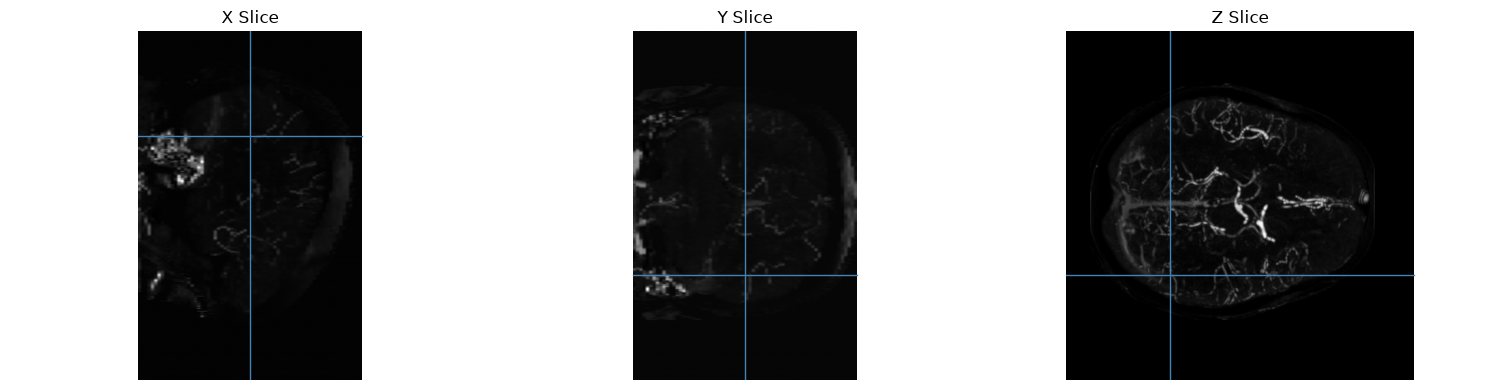

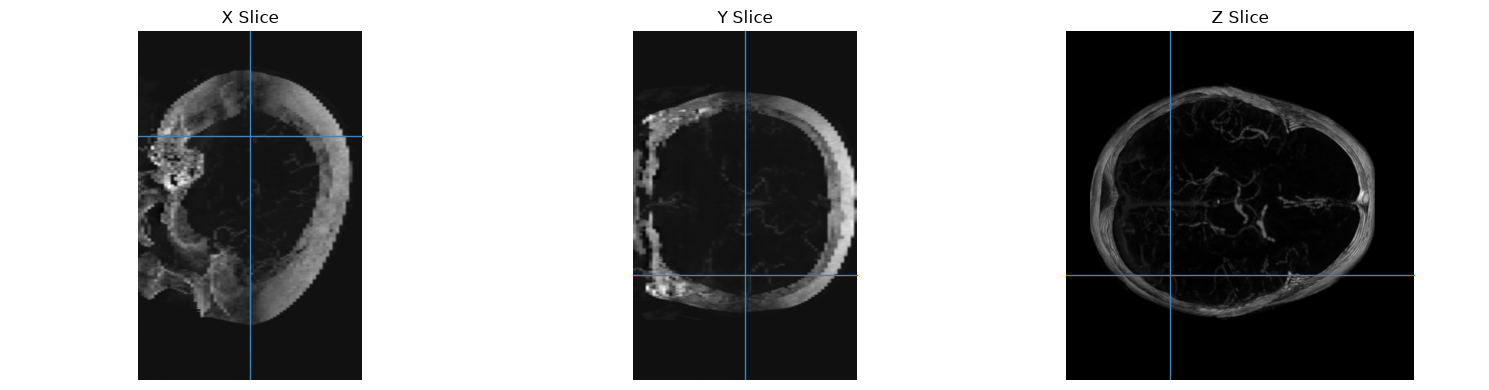

In [46]:
data_inp_recn = data_out_raw - data_out_vess
data_out_recn = data_inp_raw + data_out_vess

slices = (0.7, 0.3, 0.5)
thicknesses = (20, 20, 10)
data_inp = data_inp_raw.apply_tfm(lambda x, affine, header: (x>0) * x)
data_out = data_out_raw.apply_tfm(lambda x, affine, header: (x>0) * x)
diff = (data_out-data_inp).apply_tfm(lambda data, affine, header: data)
(diff*rest_mask).plot_slices(slices, thicknesses)
diff.plot_slices(slices, thicknesses)